## Preliminary Data Exploration

In [1]:
import pandas as pd

In [2]:
# Load the dataset
df = pd.read_csv('./data/resale_transactions.csv')
df.head()

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
0,1,2018-05,5 ROOM,118,PASIR RIS ST 11,07 TO 09,123.0,1989,70 years 03 months,488000.0,17,5,PASIR RIS,Improved
1,2,2016-10,4 ROOM,101,RIVERVALE WALK,01 TO 03,100.0,1999,81,345000.0,21,8,SENGKANG,Model A
2,3,2018-10,5 ROOM,688A,CHOA CHU KANG DR,19 TO 21,110.0,2002,82 years 06 months,370000.0,9,5,CHOA CHU KANG,Improved
3,4,2015-12,4 ROOM,130,LOR AH SOO,13 TO 15,103.0,1984,67,432000.0,12,8,HOUGANG,Model A
4,5,2017-09,5 ROOM,533,SERANGOON NTH AVE 4,07 TO 09,122.0,1992,74 years 02 months,500000.0,22,5,SERANGOON,Improved


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 88688 entries, 0 to 88687
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   88688 non-null  int64  
 1   month                88688 non-null  str    
 2   flat_type            88688 non-null  str    
 3   block                88688 non-null  str    
 4   street_name          88688 non-null  str    
 5   storey_range         88688 non-null  str    
 6   floor_area_sqm       88688 non-null  float64
 7   lease_commence_date  88688 non-null  int64  
 8   remaining_lease      88688 non-null  str    
 9   resale_price         88688 non-null  float64
 10  town_id              88688 non-null  int64  
 11  flatm_id             88688 non-null  int64  
 12  town_name            87905 non-null  str    
 13  flatm_name           88174 non-null  str    
dtypes: float64(2), int64(4), str(8)
memory usage: 15.2 MB


Two columns stand out with missing data: `town_name` and `flatm_name` both show fewer non-null entries than the rest.

In [4]:
# Check for missing values
df.isna().sum()

id                       0
month                    0
flat_type                0
block                    0
street_name              0
storey_range             0
floor_area_sqm           0
lease_commence_date      0
remaining_lease          0
resale_price             0
town_id                  0
flatm_id                 0
town_name              783
flatm_name             514
dtype: int64

`town_name` is missing 783 values and `flatm_name` is missing 514.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,88688.0,42233.303739,24376.312037,1.0,21136.75,42228.5,63339.25,84465.0
floor_area_sqm,88688.0,97.520444,24.197379,31.0,76.00,96.0,112.00,280.0
lease_commence_date,88688.0,1570.225352,1226.315949,-2016.0,1980.00,1988.0,2000.00,2016.0
resale_price,88688.0,438679.303299,146670.254508,160000.0,335000.00,408000.0,505000.00,1200000.0
town_id,88688.0,14.631337,8.032285,1.0,8.00,15.0,22.00,26.0
flatm_id,88688.0,8.889185,3.906898,1.0,5.00,8.0,12.00,21.0


`lease_commence_date` contains negative values which should not exist, a data entry glitch.

In [6]:
# Check for duplicates
df.duplicated().sum()

np.int64(4223)

There are 4,223 duplicate rows in the data.

In [7]:
# Identify duplicates
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
103,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
88570,104,2016-09,3 ROOM,201E,TAMPINES ST 23,04 TO 06,68.0,-1987,70,305000.0,23,12,TAMPINES,New Generation
106,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
88156,107,2015-08,4 ROOM,146,SERANGOON NTH AVE 1,13 TO 15,83.0,-1987,70,355000.0,22,17,SERANGOON,Simplified
114,115,2017-03,4 ROOM,274D,PUNGGOL PL,16 TO 18,93.0,2013,95 years 04 months,560000.0,18,13,PUNGGOL,Premium Apartment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87372,84427,2019-01,5 ROOM,348D,YISHUN AVE 11,13 TO 15,112.0,2013,93 years 09 months,758000.0,26,4,YISHUN,DBSS
84428,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
85835,84429,2018-10,4 ROOM,838,HOUGANG CTRL,04 TO 06,100.0,-1997,77 years 05 months,530000.0,12,8,HOUGANG,Model A
84461,84462,2015-06,5 ROOM,596A,ANG MO KIO ST 52,07 TO 09,110.0,2002,86,760000.0,1,5,ANG MO KIO,Improved


In [8]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

## Univariate Analysis

### Bar Chart

I want to look at the frequency distribution of `flat_type`.

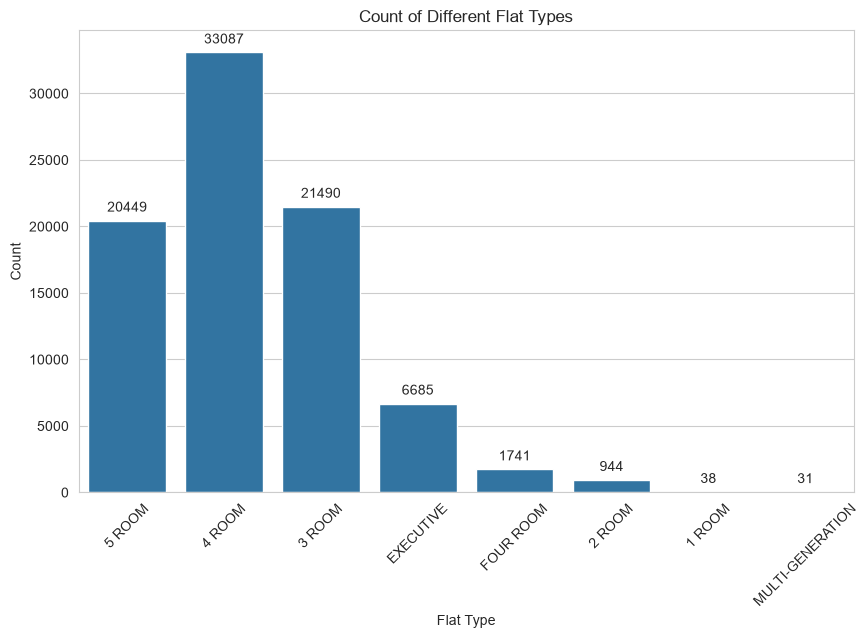

In [10]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Bar chart for flat type with annotations
plt.figure(figsize=(10, 6))
count_plot = sns.countplot(x='flat_type', data=df)
plt.title('Count of Different Flat Types')
plt.xlabel('Flat Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

# Annotate the bars with the frequency count
for p in count_plot.patches:
    count_plot.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points')

plt.show()

The most common flat types sold are the mid-sized units, with '4 ROOM' flats being the most common, followed by '3 ROOM' and '5 ROOM' flats. In comparison, '1 ROOM' and 'MULTI-GENERATION' flats are much less common in the dataset.

I also noticed a data discrepancy where "4 ROOM" and "FOUR ROOM" appear to refer to the same flat type. This may be due to inconsistent labelling during data collection and should be standardised before further analysis to avoid affecting the results.

In [11]:
# Replace 'FOUR ROOM' with '4 ROOM' in the 'flat_type' column
df['flat_type'] = df['flat_type'].replace('FOUR ROOM', '4 ROOM')
  
# Verify the changes
print(df['flat_type'].value_counts())

flat_type
4 ROOM              34828
3 ROOM              21490
5 ROOM              20449
EXECUTIVE            6685
2 ROOM                944
1 ROOM                 38
MULTI-GENERATION       31
Name: count, dtype: int64


### Histogram

I want to look at the distribution of `resale_price`. Since `resale_price` is a continuous data, using Histogram is more suitable as compared to Bar Chart.

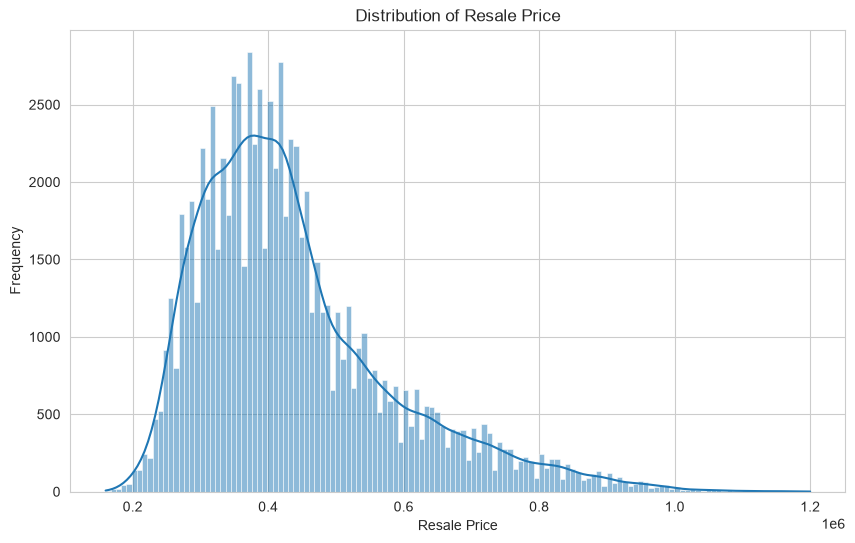

In [12]:
# Set the aesthetic style of the plots  
sns.set_style("whitegrid")  
  
# Histogram for resale price  
plt.figure(figsize=(10, 6))  
sns.histplot(df['resale_price'], kde=True)  
plt.title('Distribution of Resale Price')  
plt.xlabel('Resale Price')  
plt.ylabel('Frequency')  
plt.show()

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,84465.0,42233.000000,24383.089581,1.0,21117.0,42233.0,63349.0,84465.0
floor_area_sqm,84465.0,97.518221,24.203556,31.0,76.0,96.0,112.0,280.0
lease_commence_date,84465.0,1593.846966,1195.456328,-2016.0,1980.0,1988.0,2000.0,2016.0
resale_price,84465.0,438810.970117,146782.213376,160000.0,335000.0,408000.0,505000.0,1200000.0
town_id,84465.0,14.626851,8.032854,1.0,8.0,15.0,22.0,26.0
flatm_id,84465.0,8.886616,3.905763,1.0,5.0,8.0,12.0,21.0


The distribution of resale prices is right-skewed, with prices ranging from around $160,000 to $1.2 million. The mean resale price is approximately $438,810, while the median is $408,000. Since the mean is higher than the median, this suggests that a small number of high-value properties are pulling the average price upwards.

### Line Chart

By plotting a line chart, I can observe the frequency of listings for each month and identify any seasonal trends or anomalies.

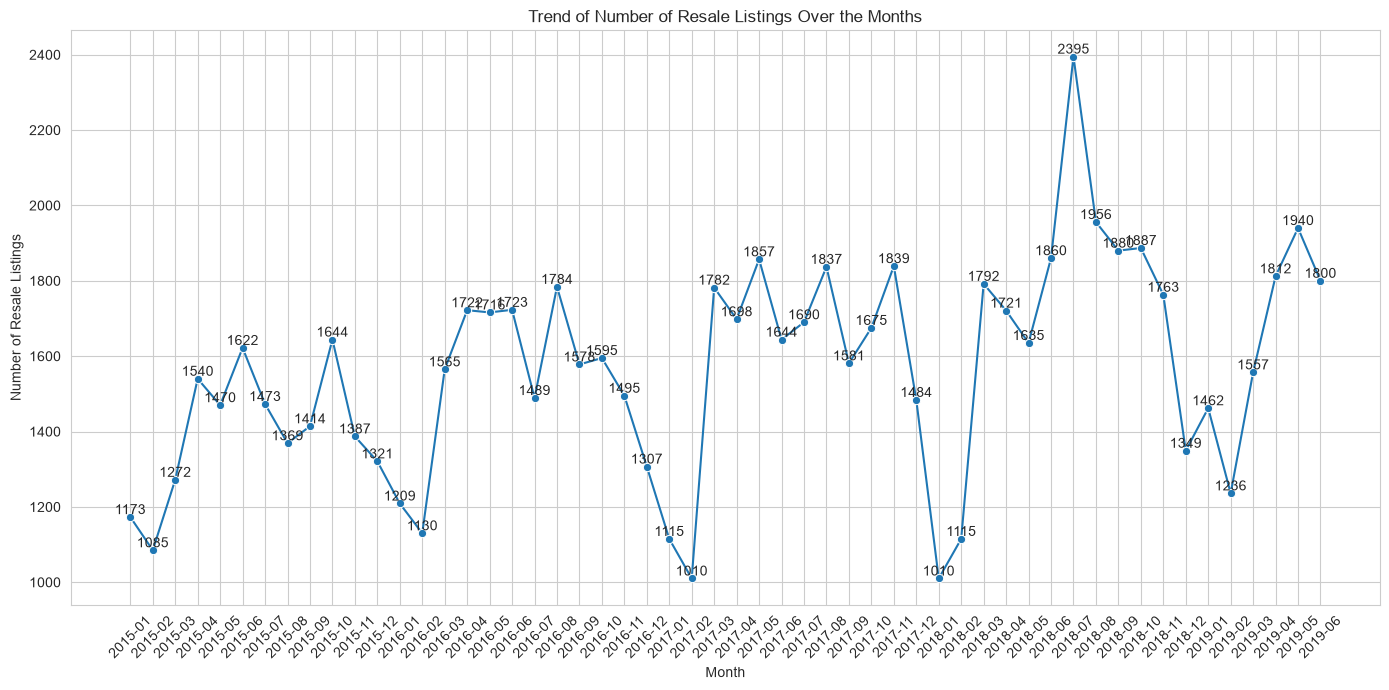

In [14]:
# Set Aesthetic Style
sns.set_style("whitegrid")

# Count the Number of Listings by Month
month_counts = df['month'].value_counts().sort_index()

# Create the Line Chart
plt.figure(figsize=(14, 7))
line_plot = sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o')

# Annotate the Data Points
for x, y in zip(month_counts.index, month_counts.values):
    plt.text(x, y, f'{y}', ha='center', va='bottom')

# Label the Chart
plt.title('Trend of Number of Resale Listings Over the Months')
plt.xlabel('Month')
plt.ylabel('Number of Resale Listings')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

July 2018 shows the highest number of listings. Based on online research, this has to be the highest since 2012. This spike is likely due to HDB flat owners' becoming more willing to accept buyers' offers due to concerns over lease decay and future price growth.

There is also a clear seasonal trend in the real estate market, with the number of listings generally falling around February each year. This could be partly explained by February being a shorter month and often coinciding with Chinese New Year, which may reduce market activity. Another possible factor is the BTO sales launch typically occurs in February, competing with resale listings for buyer attention during this period.

## Bivariate Analysis

### Box Plot

I created box plot to understand the distribution of `resale_price` by `flat_type` and identify outliers.

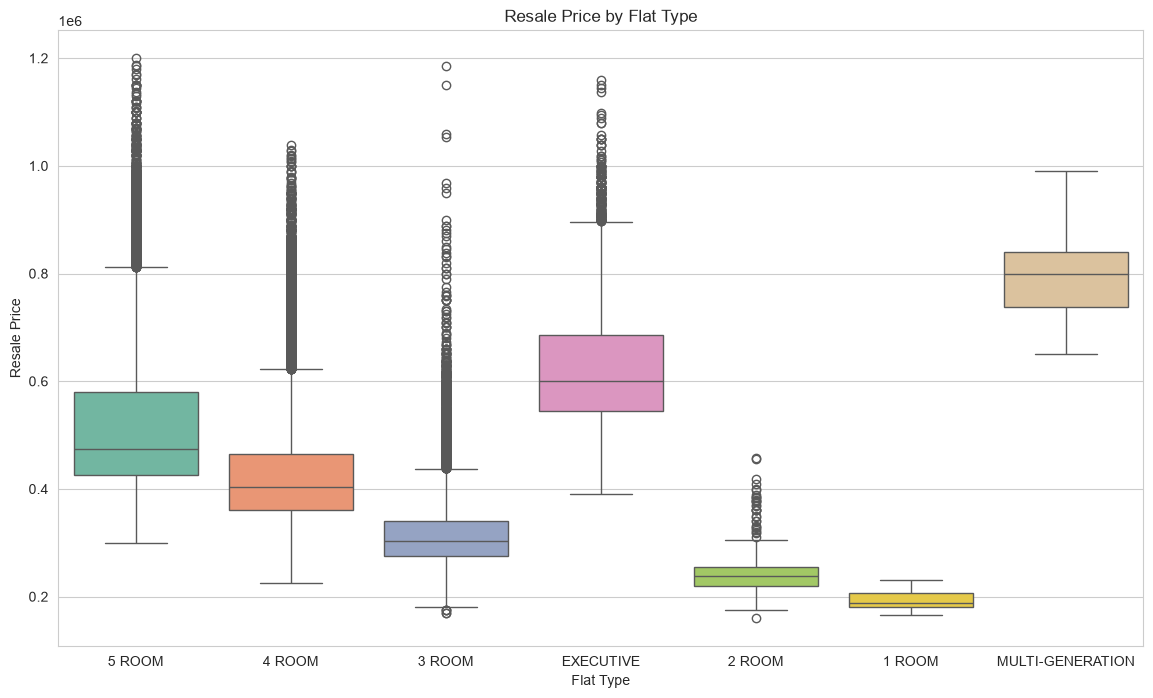

In [15]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Box plot for flat_type vs resale_price  
plt.figure(figsize=(14, 8))  
sns.boxplot(x='flat_type', y='resale_price', data=df, hue='flat_type', palette='Set2')  
plt.title('Resale Price by Flat Type')
plt.xlabel('Flat Type')
plt.ylabel('Resale Price')
plt.xticks(rotation=0)
plt.show()

The overall price distribution shows that as the flat type increases in size from '3 ROOM' to 'EXECUTIVE', the spread of prices becomes wider. In contrast, smaller flats such as 1 ROOM and 2 ROOM have lower and more compact price distributions.

The median resale price increases with the size of the flat type, which is expected as larger flats tend to be more expensive. 'EXECTUVIE' and 'MULTI-GENERATION' flats have the highest median resale prices, while '1 ROOM' and '2 ROOM' flats have the lowest.

Looking at the interquartile range (IQR), larger flat types such as 'EXECTUVIE' and 'MULTI-GENERATION' show greater variation in resale prices, while '1 ROOM' and '2 ROOM' flats are more consistent in pricing with its narrower IQRs.

There is the presence of outliers in the resale prices for '2 ROOM', '3 ROOM', '4 ROOM', '5 ROOM', and 'EXECUTIVE' flats. These outliers represent transactions that deviate significantly from the general pricing trend, possibly due to unique features or high demand in certain areas.

### Subplot Bar Chart

I discovered missing values in the `town_name` and `flatm_name` features. Based on the data dictionary, `town_id` and `flatm_id` are numerical identifiers corresponding to their respective town and flat type categories.

Since these IDs should have a consistent relationship with their corresponding names, I can compare `town_name` with `town_id` and `flatm_name` with `flatm_id` to investigate the missing values. Visualising these relationships using subplot bar charts can help identify whether each ID consistently maps to a specific category, allowing the missing names to be filled accurately based on their respective identifiers.

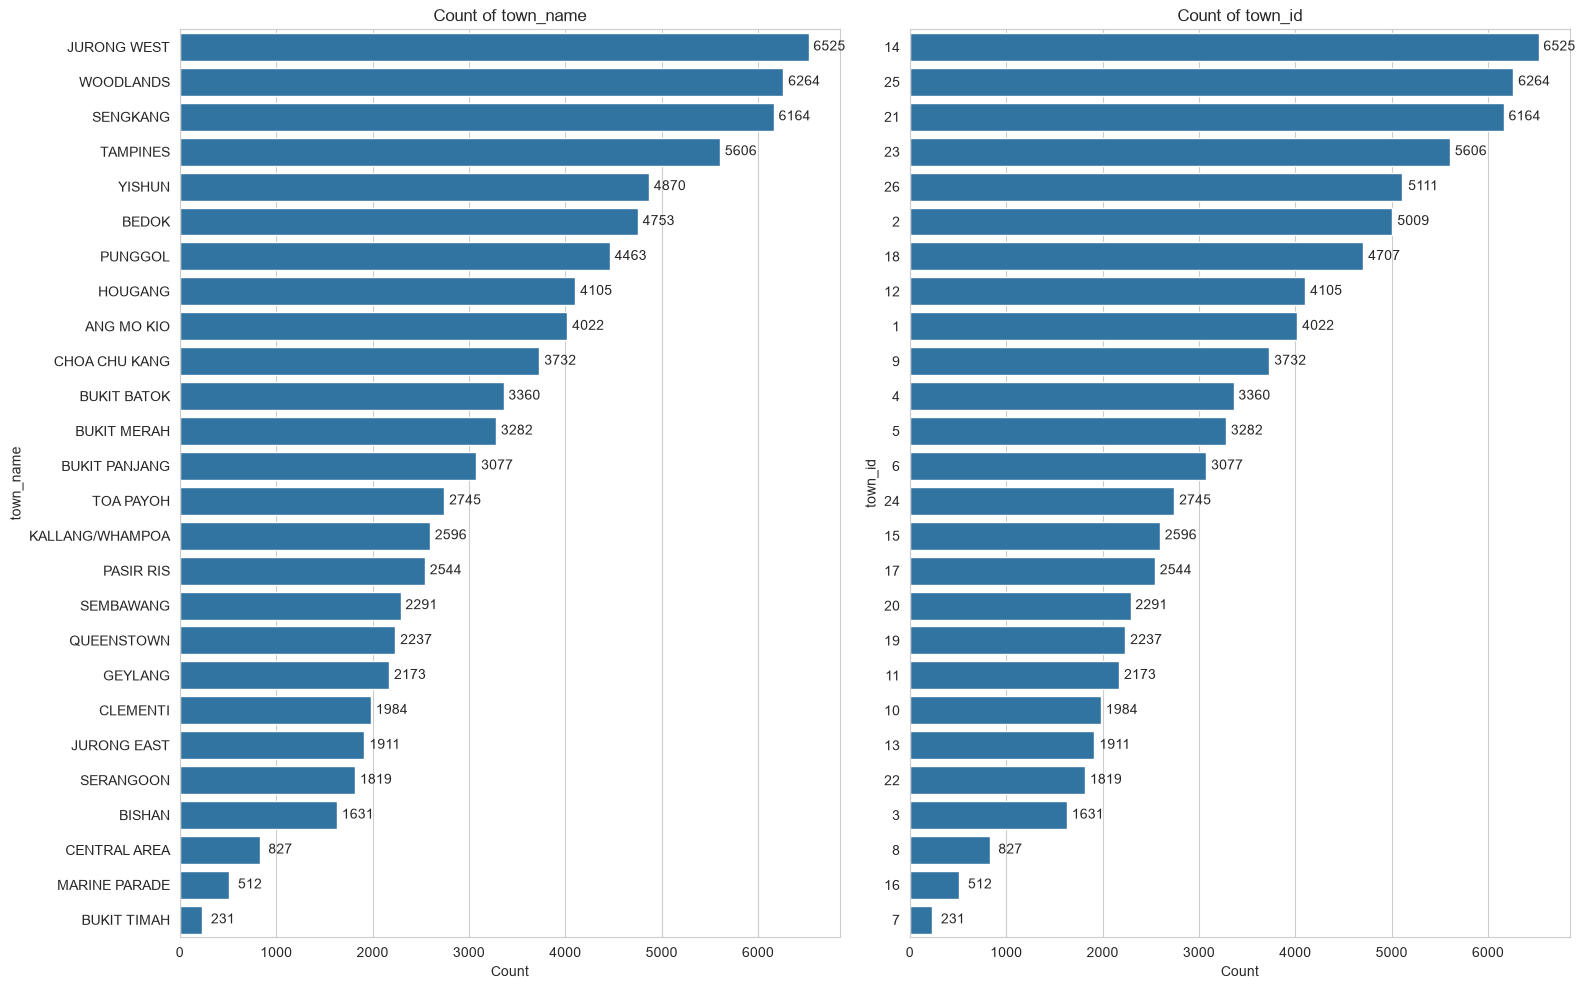

In [16]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Sort the town_name by count
sorted_town_name = df['town_name'].value_counts().index

# Count plot for town_name with annotations
count_plot_1 = sns.countplot(y='town_name', data=df, order=sorted_town_name, ax=axes[0])
axes[0].set_title('Count of town_name')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('town_name')

# Annotate the bars with the frequency count
for p in count_plot_1.patches:
    count_plot_1.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# Sort the town_id by count
sorted_town_id = df['town_id'].value_counts().index

# Count plot for town_id with annotations
count_plot_2 = sns.countplot(y='town_id', data=df, order=sorted_town_id, ax=axes[1])
axes[1].set_title('Count of town_id')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('town_id')

# Annotate the bars with the frequency count
for p in count_plot_2.patches:
    count_plot_2.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the combined plot
plt.show()

The frequencies of 'Yishun', 'Bedok', and 'Punggol' do not match the frequencies of their respective numerical identifiers, which are 26, 2, and 18, respectively.

- Missing values in 'Yishun' = 5111 - 4870 = 241
- Missing values in 'Bedok' = 5009 - 4753 = 256
- Missing values in 'Punggol' = 4707 - 4463 = 244

Total missing values = 241 + 256 + 244 = 741 

The total missing values in 'Yishun', 'Bedok', and 'Punggol' is equal to the total number of missing values in `town_name` after duplicated are removed.

The towns with the highest number of resale units are Jurong West, Woodlands, and Sengkang. These areas demonstrate a higher demand or turnover of resale properties. Conversely, the towns with the fewest resale units are Central Area, Marine Parade, and Bukit Timah. These areas have significantly lower numbers of resale transactions, indicating either lower demand or a smaller housing stock available for resale.

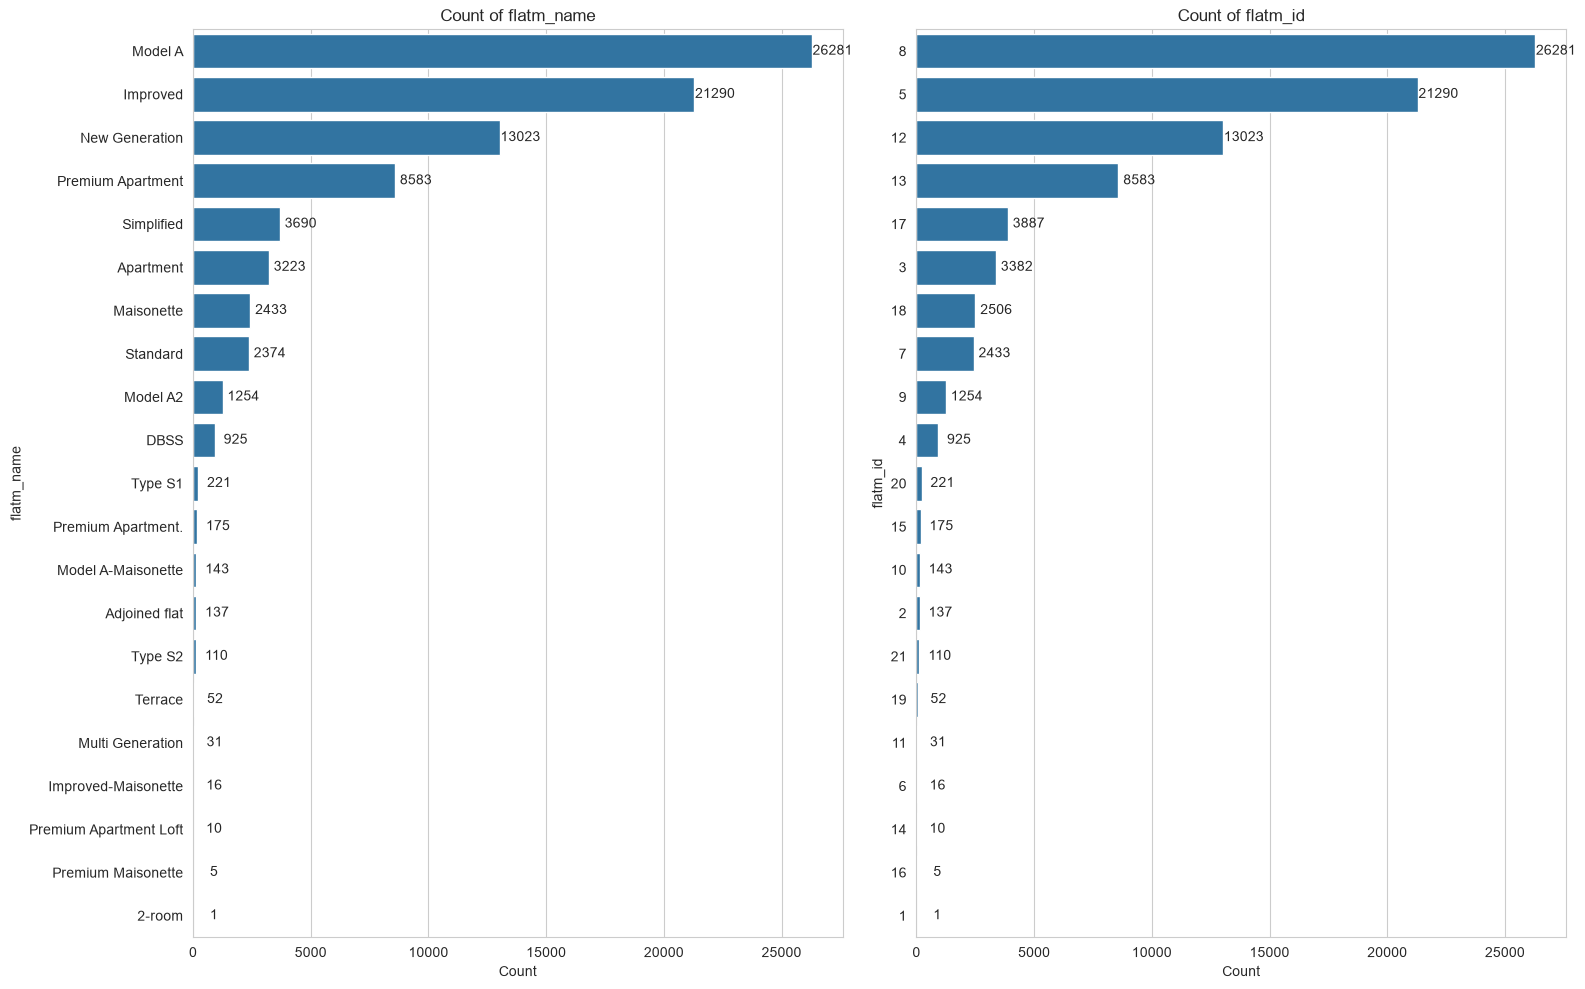

In [17]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Create a figure with 2 subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Sort the flatm_name by count
sorted_flatm_name = df['flatm_name'].value_counts().index

# Count plot for flatm_name with annotations
count_plot_1 = sns.countplot(y='flatm_name', data=df, order=sorted_flatm_name, ax=axes[0])
axes[0].set_title('Count of flatm_name')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('flatm_name')

# Annotate the bars with the frequency count
for p in count_plot_1.patches:
    count_plot_1.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# Sort the flatm_id by count
sorted_flatm_id = df['flatm_id'].value_counts().index

# Count plot for flatm_id with annotations
count_plot_2 = sns.countplot(y='flatm_id', data=df, order=sorted_flatm_id, ax=axes[1])
axes[1].set_title('Count of flatm_id')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('flatm_id')

# Annotate the bars with the frequency count
for p in count_plot_2.patches:
    count_plot_2.annotate(format(p.get_width(), '.0f'),
                          (p.get_width(), p.get_y() + p.get_height() / 2),
                          ha='center', va='center',
                          xytext=(15, 0),
                          textcoords='offset points')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the combined plot
plt.show()

The frequencies of 'Simplified', 'Apartment', 'Maisonette', and 'Standard' do not match the frequencies of their respective numerical identifiers, which are 17, 3, 18, and 7, respectively.

- Missing values in 'Simplified' = 3887 - 3690 = 197
- Missing values in 'Apartment' = 3382 - 3223 = 159
- Missing values in 'Maisonette' = 2506 - 2433 = 73
- Missing values in 'Standard' = 2433 - 2374 = 59

Total missing values = 197 + 159 + 73 + 59 = 488

The total missing values in 'Simplified', 'Apartment', 'Maisonette', and 'Standard' is equal to the total number of missing values in `flatm_name` after duplicated are removed.

Most resale flat models are 'Model A', 'Improved', or 'New Generation' because these were the standard designs HDB built the most of during the 1970s and 1980s, the peak years of Singapore's public housing program. As a result, these older designs simply make up the biggest portion of HDB flats in existence today, which is why they also dominate the resale market.

### Scatter Plot

I create scatter plot to visualise relationship between two continuous variables, identify correlations, trends, and patterns in the data.

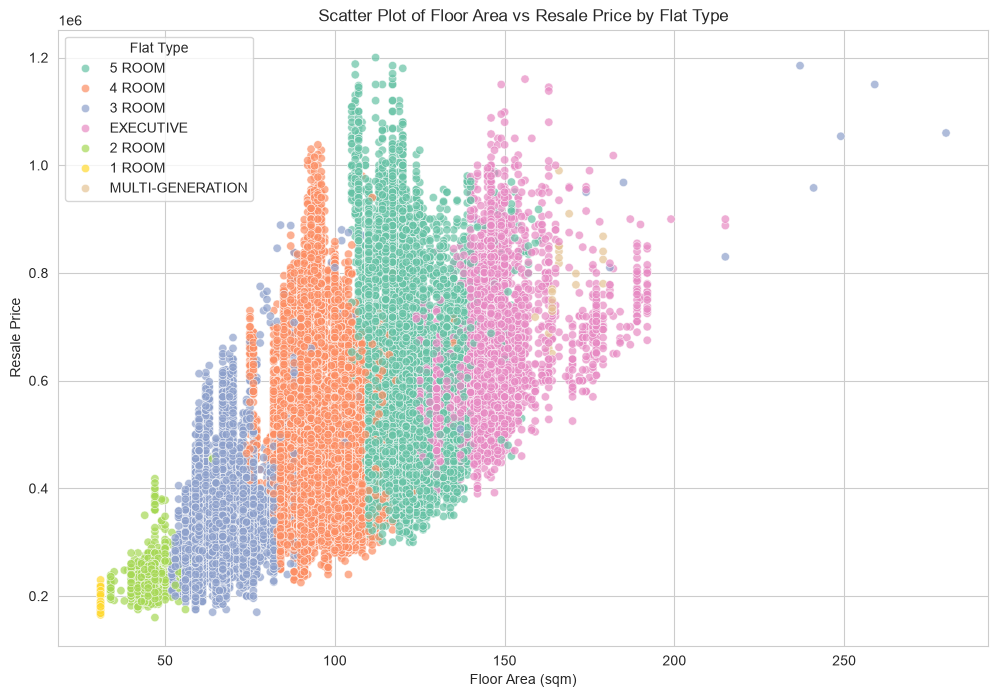

In [18]:
# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Scatter plot for floor area vs resale price with color encoding for flat type
plt.figure(figsize=(12, 8))
sns.scatterplot(x='floor_area_sqm', y='resale_price', hue='flat_type', data=df, palette='Set2', alpha=0.7)
plt.title('Scatter Plot of Floor Area vs Resale Price by Flat Type')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price')
plt.legend(title='Flat Type')
plt.show()

There is a positive trend indicating that as the floor area increases, the resale price generally increases. This trend suggests that larger flats tend to sell for higher prices.

Smaller flat types such as '1 ROOM' and '2 ROOM' cluster towards lower floor areas and resale prices. In contrast, larger flat types such as 'EXECUTIVE' and 'MULTI-GENERATION' cluster towards higher floor areas and resale prices.

The plot shows a wide spread of resale prices for similar floor areas, especially in mid-sized flats such as '3 ROOM', '4 ROOM', and '5 ROOM'. This variation could be due to other factors influencing resale prices, such as location, age of the flat, and condition.

There are a few outliers for '3 ROOM' flats having both a much higher floor area and resale price compared to other '3 ROOM' flats. This is worth performing further investigation.

#### Digging Deeper: Outlier Analysis

In [19]:
# Filter the data for outliers
outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['floor_area_sqm'] > 150) & 
                        (df['resale_price'] > 800000)]

# Display the outliers
outliers

,id,month,flat_type,block,street_name,storey_range,floor_area_sqm,lease_commence_date,remaining_lease,resale_price,town_id,flatm_id,town_name,flatm_name
856,857,2018-09,3 ROOM,41,JLN BAHAGIA,01 TO 03,237.0,1972,52 years 10 months,1185000.0,15,19,KALLANG/WHAMPOA,Terrace
7472,7473,2018-06,3 ROOM,58,JLN MA'MOR,01 TO 03,174.0,1972,53 years 02 months,950000.0,15,19,KALLANG/WHAMPOA,Terrace
31858,31859,2015-03,3 ROOM,53,JLN MA'MOR,01 TO 03,280.0,1972,56,1060000.0,15,19,KALLANG/WHAMPOA,Terrace
47739,47740,2017-12,3 ROOM,65,JLN MA'MOR,01 TO 03,249.0,1972,53 years 07 months,1053888.0,15,19,KALLANG/WHAMPOA,Terrace
51992,51993,2018-05,3 ROOM,44,JLN BAHAGIA,01 TO 03,185.0,1972,53 years 02 months,968000.0,15,19,KALLANG/WHAMPOA,Terrace
54578,54579,2016-12,3 ROOM,57,JLN MA'MOR,01 TO 03,259.0,1972,54,1150000.0,15,19,KALLANG/WHAMPOA,Terrace
61997,61998,2017-05,3 ROOM,59,JLN MA'MOR,01 TO 03,181.0,1972,54 years 02 months,810000.0,15,19,KALLANG/WHAMPOA,Terrace
66428,66429,2017-06,3 ROOM,38,JLN BAHAGIA,01 TO 03,215.0,1972,54 years 01 month,830000.0,15,19,KALLANG/WHAMPOA,Terrace
78787,78788,2015-06,3 ROOM,60,JLN BAHAGIA,01 TO 03,241.0,1972,56,958000.0,15,19,KALLANG/WHAMPOA,Terrace


These outliers, with floor areas above 150 square meters and resale prices above $800,000, are all 3-room Terrace flats.

In [20]:
# Further filter the data for 3-room terrace flats
terrace_outliers = df[(df['flat_type'] == '3 ROOM') & 
                        (df['flatm_name'] == "Terrace")]

# Display the outliers
terrace_outliers.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48.0,48168.062500,22777.117131,857.0,31793.75,51140.5,65752.50,83890.0
floor_area_sqm,48.0,117.708333,55.604974,78.0,83.00,93.0,113.25,280.0
lease_commence_date,48.0,1889.166667,569.171078,-1972.0,1972.00,1972.0,1972.00,1972.0
resale_price,48.0,813840.685000,122974.848464,635000.0,730000.00,795000.0,871250.00,1185000.0
town_id,48.0,15.666667,1.506487,15.0,15.00,15.0,15.00,19.0
flatm_id,48.0,19.000000,0.000000,19.0,19.00,19.0,19.00,19.0


Based on online research, these flats refer to HDB terrace houses, a type of public housing that is no longer being built by the government. A total of 285 HDB terrace houses were built in the Whampoa and Queenstown areas during the 1950s. These properties are typically spread across two storeys and include a backyard, which helps explain their relatively large floor areas. Like other HDB properties, they are sold on a 99-year leasehold.

In the dataset, the resale prices of these terrace houses range from $635,000 to $1.185 million. Their floor areas also vary considerably, with the smallest measuring 78 square metres and the largest measuring 280 square metres.

Although these 3-room Terrace flats have larger floor areas and higher resale prices than typical 3-room flats, further investigation confirms they represent real, meaningful data rather than data errors. Removing them would therefore discard legitimate signal from the dataset.

## Correlation Analysis

### Heatmap

In [21]:
# Function to convert storey_range to ordinal scale by taking the average of the range
def convert_storey_range(storey_range: str) -> float:
    """
    Converts a storey range string into its average numerical value.
    
    The function takes a storey range in the format 'XX TO YY', splits it into two parts,
    converts these parts to integers, and returns the average of these integers.
    
    Args:
        storey_range (str): A string representing a range of storeys, in the format 'XX TO YY'.
        
    Returns:
        float: The average value of the two storeys in the range.
        
    Example:
        convert_storey_range('07 TO 09') -> 8.0
    """
    range_values = storey_range.split(' TO ')
    return (int(range_values[0]) + int(range_values[1])) / 2

# Use the .apply() method to convert the 'storey_range' column with the function
df['storey_range'] = df['storey_range'].apply(convert_storey_range)

For this correlation analysis, I will use Spearman rank correlation instead of Pearson correlation. Spearman ranks the data before computing correlation, making it less sensitive to outliers and skewed distributions. This is particularly relevant to this dataset, as the scatter plot shows some extreme values from 3-room Terrace flats, while resale_price is also right-skewed.

Another reason for using Spearman is that it can capture monotonic relationships, even when the relationship is not perfectly linear. This is useful for variables such as `floor_area_sqm` and `resale_price`, where the relationship appears to increase overall but may not follow a straight-line pattern.

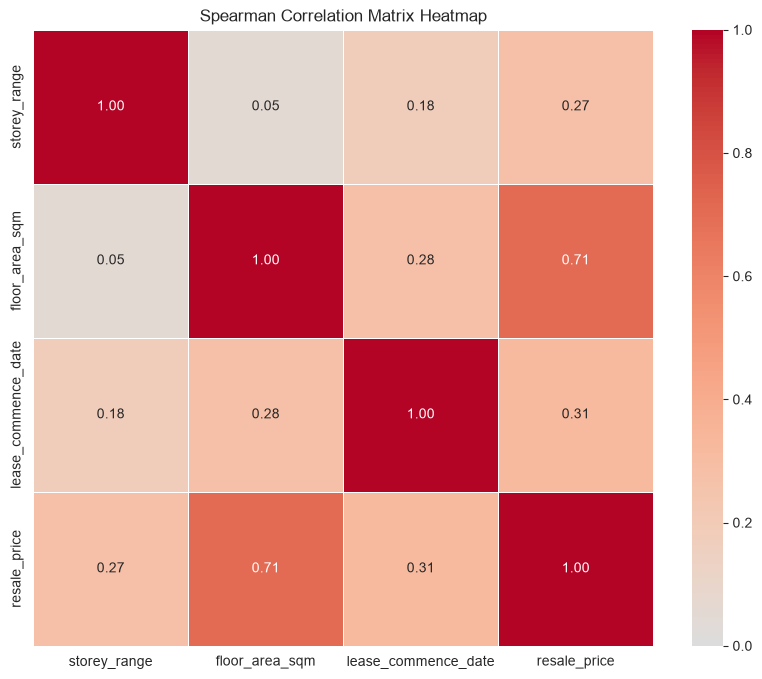

In [22]:
# Select relevant columns for correlation analysis
spearman_vars = df[['storey_range', 'floor_area_sqm', 'lease_commence_date', 'resale_price']]

# Compute the Spearman correlation matrix
spearman_corr = spearman_vars.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, vmin=0, vmax=1, linewidths=0.5, fmt=".2f")
plt.title('Spearman Correlation Matrix Heatmap')
plt.show()

1. There is a strong positive monotonic correlation between the 'floor_area' and the 'resale_price'. Larger flats tend to have higher resale prices, and this relationship is relatively strong.

2. There is a moderate positive monotonic relationship between the 'lease_commence_date' and the 'resale_price'. Flats with more recent lease commencement dates tend to have higher resale prices.

3. There is a weak positive monotonic correlation between the 'storey_range' and the 'resale_price'. Higher storey flats tend to have higher resale prices, but the relationship is not strong.

In [23]:
df.to_csv("data/eda.csv", index=False)